## SmartSMS - SMS Spam Classification

#description:
An NLP-based machine learning project for classifying SMS
messages as Spam or Ham.

#project objective:
The objective of this project is to develop a machine learning
system that can automatically classify SMS messages as either
spam or legitimate (ham) messages using Natural Language
Processing and machine learning techniques.

#machine learning work flow

1. Data Loading
2. Data Cleaning
3. Exploratory Data Analysis
4. Text Preprocessing
5. Feature Extraction using TF-IDF
6. Model Training
7. Model Comparison
8. Model Evaluation
9. Best Model Selection
10. Model Saving

## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import string

from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

Matplotlib is building the font cache; this may take a moment.


##setup NLTK 

In [2]:
nltk.download('stopwords')
nltk.download('punkt_tab')

ps = PorterStemmer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MSI\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\MSI\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


## Load Dataset

##load the data set "spam.csv"

In [3]:
df = pd.read_csv(
    "../data/spam.csv",
    encoding="latin-1"
)

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


##check the data set properly

In [4]:
df.shape


(5572, 5)

In [5]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [8]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

## Data Cleaning

##clean the columns

In [9]:
df = df[['v1', 'v2']]

df.columns = ['class', 'sms']

df.head()

,class,sms
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


##check missing values

In [10]:
df.isnull().sum()

class    0
sms      0
dtype: int64

In [11]:
df['class'].value_counts()
##this gives the number of ham and spams in dataset

class
ham     4825
spam     747
Name: count, dtype: int64

##remove duplicate messages

In [12]:
df = df.drop_duplicates(keep='first')

df = df.reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (5169, 2)


In [13]:
df['class'].value_counts()

class
ham     4516
spam     653
Name: count, dtype: int64

## Exploratory Data Analysis

##Add a proper EDA section

-------------Exploratory Data Analysis--------------

Before training the machine learning models, the dataset is
explored to understand the distribution of spam and ham messages
and the characteristics of the SMS text.

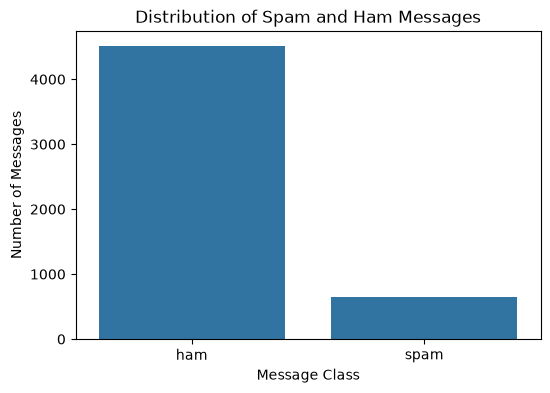

In [14]:
##visualization of the dataset
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x='class'
)

plt.title('Distribution of Spam and Ham Messages')
plt.xlabel('Message Class')
plt.ylabel('Number of Messages')

plt.show()

##add the 'Length' column

In [27]:
# Add message length
df['Length'] = df['sms'].astype(str).str.len()

# Check that it was created
print(df[['class', 'sms', 'Length']].head())

  class                                                sms  Length
0   ham  Go until jurong point, crazy.. Available only ...     111
1   ham                      Ok lar... Joking wif u oni...      29
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...     155
3   ham  U dun say so early hor... U c already then say...      49
4   ham  Nah I don't think he goes to usf, he lives aro...      61


##Add message length

In [28]:
df.groupby('class')['Length'].describe()

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
ham,4516.0,70.459256,56.358207,2.0,34.0,52.0,90.0,910.0
spam,653.0,137.891271,30.137753,13.0,132.0,149.0,157.0,224.0


##visualize message length

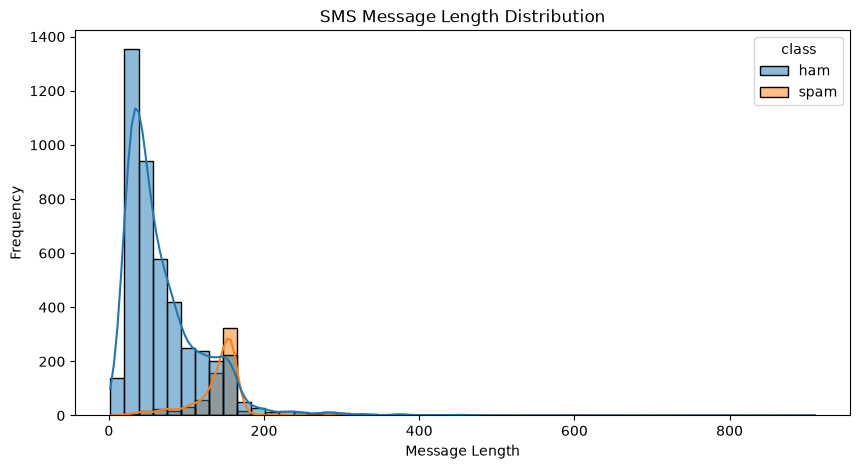

In [30]:
##show with a graph 
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='Length',
    hue='class',
    bins=50,
    kde=True
)

plt.title('SMS Message Length Distribution')
plt.xlabel('Message Length')
plt.ylabel('Frequency')

plt.show()


## NLP Preprocessing

##Create the preprocessing function

 NLP Text Preprocessing
 
 The SMS messages are converted into a normalized textual
representation using:

- Lowercase conversion
- Tokenization
- Removal of non-alphanumeric tokens
- Stop-word removal
- Punctuation removal
- Stemming

In [31]:
def clean_text(text):
    text = str(text).lower()

    tokens = nltk.word_tokenize(text)

    filtered_tokens = []

    for token in tokens:
        if token.isalnum():
            filtered_tokens.append(token)

    filtered_tokens_no_stopwords = []

    for token in filtered_tokens:
        if token not in stopwords.words('english'):
            filtered_tokens_no_stopwords.append(token)

    stemmed_tokens = []

    for token in filtered_tokens_no_stopwords:
        stemmed_tokens.append(ps.stem(token))

    return " ".join(stemmed_tokens)

##Test the preprocessing before applying it

In [32]:
sample_message = df['sms'].iloc[2]

print("Original:")
print(sample_message)

print("\nCleaned:")
print(clean_text(sample_message))

Original:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

Cleaned:
free entri 2 wkli comp win fa cup final tkt 21st may text fa 87121 receiv entri question std txt rate c appli 08452810075over18


## Train/Test Split

##Split the data 

In [33]:
X = df['sms']
y = df['class']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

##Clean the training and testing text separately

In [36]:
X_train_clean = X_train.apply(clean_text)
X_test_clean = X_test.apply(clean_text)

##  TF-IDF Feature Extraction

##TF-IDF

In [37]:
tfidf = TfidfVectorizer(
    max_features=3000
)

In [41]:
X_train_tfidf = tfidf.fit_transform(X_train_clean)

X_test_tfidf = tfidf.transform(X_test_clean)

##Check the feature matrix

In [42]:
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (4135, 3000)
Testing shape: (1034, 3000)


##  Model Training

##First model- Naive Bayes

In [43]:
nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3613., 522.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.13,-2.07]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U4](2,)","['ham','spam']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 3000)","[[ 0. , 0. , 0. ,..., 0.38, 0.27,16.19], [ 0.53, 0.41, 0.26,..., 0. , 0. , 0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 3000)","[[-9.34,-9.34,-9.34,...,-9.02,-9.1 ,-6.49], [-8.04,-8.12,-8.23,...,-8.46,-8.46,-8.46]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3000


In [44]:
nb_predictions = nb_model.predict(X_test_tfidf)

In [45]:
nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.9700193423597679


##Model Training and Comparison

Multiple machine learning algorithms are trained and evaluated
to determine which model performs best for SMS spam classification.

The models considered are:

1. Multinomial Naive Bayes
2. Logistic Regression
3. Linear Support Vector Machine (SVM)

##Evaluate the Naive Bayes model 

In [46]:
nb_accuracy = accuracy_score(y_test, nb_predictions)
nb_precision = precision_score(y_test, nb_predictions, pos_label='spam')
nb_recall = recall_score(y_test, nb_predictions, pos_label='spam')
nb_f1 = f1_score(y_test, nb_predictions, pos_label='spam')

print("Naive Bayes")
print("----------------------")
print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)

Naive Bayes
----------------------
Accuracy : 0.9700193423597679
Precision: 0.9807692307692307
Recall   : 0.7786259541984732
F1 Score : 0.8680851063829788


##Generating a classification report

In [47]:
print(classification_report(
    y_test,
    nb_predictions
))

              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       903
        spam       0.98      0.78      0.87       131

    accuracy                           0.97      1034
   macro avg       0.97      0.89      0.93      1034
weighted avg       0.97      0.97      0.97      1034



##creating the confusion matrix

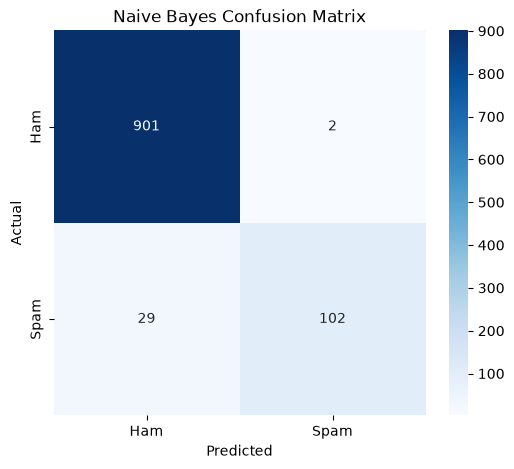

In [48]:
cm = confusion_matrix(
    y_test,
    nb_predictions,
    labels=['ham', 'spam']
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## MODEL 2 - Logistic Regression

In [49]:
lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [50]:
lr_predictions = lr_model.predict(X_test_tfidf)

In [51]:
lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_precision = precision_score(
    y_test,
    lr_predictions,
    pos_label='spam'
)
lr_recall = recall_score(
    y_test,
    lr_predictions,
    pos_label='spam'
)
lr_f1 = f1_score(
    y_test,
    lr_predictions,
    pos_label='spam'
)

print("Logistic Regression")
print("----------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Logistic Regression
----------------------
Accuracy : 0.9622823984526112
Precision: 1.0
Recall   : 0.7022900763358778
F1 Score : 0.8251121076233184


In [52]:
print(classification_report(
    y_test,
    lr_predictions
))

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       903
        spam       1.00      0.70      0.83       131

    accuracy                           0.96      1034
   macro avg       0.98      0.85      0.90      1034
weighted avg       0.96      0.96      0.96      1034



## MODEL 3 - Linear SVM

##Linear Support Vector Machine

In [53]:
svm_model = LinearSVC()

svm_model.fit(
    X_train_tfidf,
    y_train
)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [54]:
svm_predictions = svm_model.predict(
    X_test_tfidf
)

In [55]:
svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

svm_precision = precision_score(
    y_test,
    svm_predictions,
    pos_label='spam'
)

svm_recall = recall_score(
    y_test,
    svm_predictions,
    pos_label='spam'
)

svm_f1 = f1_score(
    y_test,
    svm_predictions,
    pos_label='spam'
)

print("Linear SVM")
print("----------------------")
print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1 Score :", svm_f1)

Linear SVM
----------------------
Accuracy : 0.9796905222437138
Precision: 0.9741379310344828
Recall   : 0.8625954198473282
F1 Score : 0.9149797570850202


In [56]:
print(classification_report(
    y_test,
    svm_predictions
))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       903
        spam       0.97      0.86      0.91       131

    accuracy                           0.98      1034
   macro avg       0.98      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034



## Model Comparison

##comparing by creating a dataframe

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Multinomial Naive Bayes(model 1)',
        'Logistic Regression(model 2)',
        'Linear SVM(model 3)'
    ],
    
    'Accuracy': [
        nb_accuracy,
        lr_accuracy,
        svm_accuracy
    ],
    
    'Precision': [
        nb_precision,
        lr_precision,
        svm_precision
    ],
    
    'Recall': [
        nb_recall,
        lr_recall,
        svm_recall
    ],
    
    'F1 Score': [
        nb_f1,
        lr_f1,
        svm_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes(model 1),0.970019,0.980769,0.778626,0.868085
1,Logistic Regression(model 2),0.962282,1.000000,0.702290,0.825112
2,Linear SVM(model 3),0.979691,0.974138,0.862595,0.914980


##Visualize the comparison

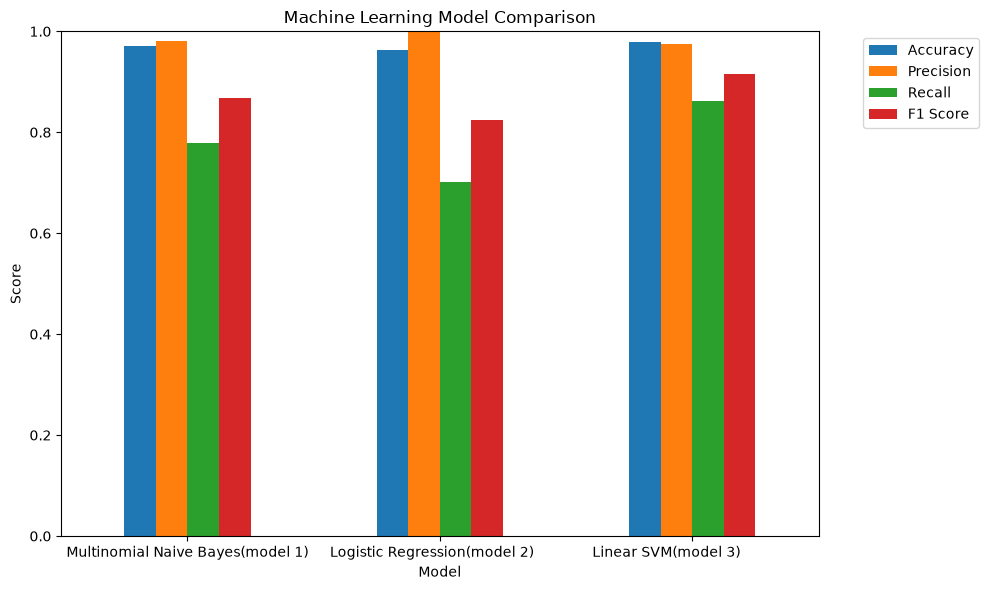

In [61]:
results.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score']
].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Machine Learning Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

## Selecting the best model

In [62]:
best_model_name = results.loc[
    results['F1 Score'].idxmax(),
    'Model'
]

best_model_name

'Linear SVM(model 3)             '

In [63]:
print(
    f"Best model based on F1 Score: {best_model_name}"
)

Best model based on F1 Score: Linear SVM(model 3)             


## Error Analysis

reading the messages that model get wrong

In [64]:
error_analysis = pd.DataFrame({
    'message': X_test,
    'actual': y_test,
    'predicted': nb_predictions
})

errors = error_analysis[
    error_analysis['actual'] != error_analysis['predicted']
]

errors.head(20)

,message,actual,predicted
1458,Thanks for the Vote. Now sing along with the s...,spam,ham
5137,Want explicit SEX in 30 secs? Ring 02073162414...,spam,ham
2695,Send a logo 2 ur lover - 2 names joined by a h...,spam,ham
483,Congrats! 1 year special cinema pass for 2 is ...,spam,ham
2906,"Hi babe its Jordan, how r u? Im home from abro...",spam,ham
1610,Hi if ur lookin 4 saucy daytime fun wiv busty ...,spam,ham
4752,TheMob>Hit the link to get a premium Pink Pant...,spam,ham
1892,Guess what! Somebody you know secretly fancies...,spam,ham
5139,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,spam,ham
1422,Hi its LUCY Hubby at meetins all day Fri & I w...,spam,ham


In [65]:
print("Number of incorrect predictions:", len(errors))

Number of incorrect predictions: 31


##Finding false positives and false negatives

False positives  
Normal messages that the model incorrectly classified as spam.

In [66]:
false_positives = error_analysis[
    (error_analysis['actual'] == 'ham') &
    (error_analysis['predicted'] == 'spam')
]

false_positives.head(10)


,message,actual,predicted
4536,Nokia phone is lovly..,ham,spam
4600,K..k.:)congratulation ..,ham,spam


##False negatives  
Spam messages that the model failed to detect.

In [67]:
false_negatives = error_analysis[
    (error_analysis['actual'] == 'spam') &
    (error_analysis['predicted'] == 'ham')
]

false_negatives.head(10)

,message,actual,predicted
1458,Thanks for the Vote. Now sing along with the s...,spam,ham
5137,Want explicit SEX in 30 secs? Ring 02073162414...,spam,ham
2695,Send a logo 2 ur lover - 2 names joined by a h...,spam,ham
483,Congrats! 1 year special cinema pass for 2 is ...,spam,ham
2906,"Hi babe its Jordan, how r u? Im home from abro...",spam,ham
1610,Hi if ur lookin 4 saucy daytime fun wiv busty ...,spam,ham
4752,TheMob>Hit the link to get a premium Pink Pant...,spam,ham
1892,Guess what! Somebody you know secretly fancies...,spam,ham
5139,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,spam,ham
1422,Hi its LUCY Hubby at meetins all day Fri & I w...,spam,ham


## Create the final model 
Linear SVM

In [68]:
final_model = LinearSVC()

final_model.fit(
    X_train_tfidf,
    y_train
)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [69]:
final_predictions = final_model.predict(
    X_test_tfidf
)

In [70]:
print(classification_report(
    y_test,
    final_predictions
))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       903
        spam       0.97      0.86      0.91       131

    accuracy                           0.98      1034
   macro avg       0.98      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034



## Saving the model
import library

In [71]:
import joblib

In [73]:
##create
joblib.dump(
    final_model,
    "../models/spam_model.pkl"
)

##trained ML model is saved in the models folder as spam_model.pkl

['../models/spam_model.pkl']

##Save the TF-IDF vectorizer

In [74]:
joblib.dump(
    tfidf,
    "../models/tfidf_vectorizer.pkl"
)

['../models/tfidf_vectorizer.pkl']

this tfidf_vectorizer.pkl converts text into numbers.   
spam_model.pkl converts numbers into spam / ham

##load for test

In [75]:
loaded_model = joblib.load(
    "../models/spam_model.pkl"
)

loaded_tfidf = joblib.load(
    "../models/tfidf_vectorizer.pkl"
)

In [ ]:
##create a message for testing.
##spam message testing
test_message = "Congratulations! You have won a free prize. Call now!"

In [77]:
##clean it.
cleaned_message = clean_text(test_message)

In [78]:
##transform it 
message_vector = loaded_tfidf.transform(
    [cleaned_message]
)

In [79]:
##predict it
prediction = loaded_model.predict(
    message_vector
)

print("Prediction:", prediction[0])

Prediction: spam


In [80]:
##ham message testing.
test_message = "Hey, are you coming to the university tomorrow?"

In [81]:
##clean and then predict
cleaned_message = clean_text(test_message)

message_vector = loaded_tfidf.transform(
    [cleaned_message]
)

prediction = loaded_model.predict(
    message_vector
)

print("Prediction:", prediction[0])

Prediction: ham


##adding a reusable function for prediction

In [82]:
def predict_spam(message, model, vectorizer):
    
    cleaned_message = clean_text(message)
    
    message_vector = vectorizer.transform(
        [cleaned_message]
    )
    
    prediction = model.predict(
        message_vector
    )
    
    return prediction[0]

In [83]:
message = "Congratulations! You won a free prize!"

result = predict_spam(
    message,
    loaded_model,
    loaded_tfidf
)

print("Prediction:", result)

Prediction: spam


In [85]:
message = "Are you free for lunch today?"

result = predict_spam(
    message,
    loaded_model,
    loaded_tfidf
)

print("Prediction:", result)

Prediction: ham
